# Principal Component Analysis (PCA) on Customer Credit Card Data
This notebook performs PCA, visualizes explained variance ratio, fits a 2D PCA, and saves the pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import joblib


In [2]:
df = pd.read_csv('CC GENERAL.csv')
X = df.drop(columns=['CUST_ID'])

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_scaled = preprocessor.fit_transform(X)


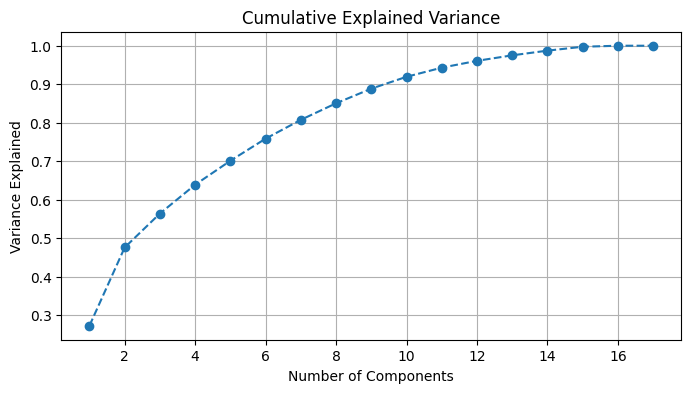

In [3]:
# Fit PCA and plot explained variance
pca = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()


In [4]:
# Save a 2-component PCA pipeline for 2D visualization
pca_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2, random_state=42))
])
pca_pipeline.fit(X)
joblib.dump(pca_pipeline, 'pca_model.pkl')
print('PCA 2D Pipeline saved successfully!')


PCA 2D Pipeline saved successfully!
